In [9]:
import sys
import os
import scipy as sp
import urllib3

# Set the current and parent paths
current_path = os.getcwd()
parent_path = os.path.dirname(current_path)
sys.path.append(parent_path)

# Import custom modules
import funcTidal
import funcRotor
import funcConstraint
import funcSimRotor
import funcLCOE
import funcMain
import constUnitConvert
import constGlobal
import constVessel

# Initialize constants and unit conversion
CONVERT = constUnitConvert.ConstantsUnitConversion()
GLOBAL = constGlobal.ConstantsGlobal()

# Disable the InsecureRequestWarning
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)


# Brute Force Optimization Tutorial

This tutorial provides an example of performing brute force optimization.

## Step 1: Define the Simulation Conditions

First, define the simulation conditions:

- **Tidal Data**: Use the tidal data from the NOAA buoy station specified by `myStation`.
- **Cut-in Speed**: Specify the cut-in speed with `Umin`.
- **Brake Usage**: Indicate whether a brake is used with `withBrake`.
- **Vessel Properties**: Define the vessel properties with `VESSEL`.
- **Rated Power Scaling**: If you want to scale the rated power, specify `scalePrated`. **Note: This is only useful for constraint minimization. Leave this as `None` if not applicable.**

## Step 2: Define the Grid Points for Brute Force Optimization

Next, define the grid points for the brute force optimization. The variables include radius, rated power, hub depth, and the number of turbines. Each variable must be specified in the order of minimum, maximum, and step size.

- **Radius**: `RrMin`, `RrMax`, `RrStep`
- **Rated Power**: `PratedMin`, `PratedMax`, `PratedStep`
- **Hub Depth**: `dHubMin`, `dHubMax`, `dHubStep`
- **Number of Turbines**: `nTurbineMin`, `nTurbineMax`, `nTurbineStep`


In [10]:
# Define parameters for the simulation
myStation = "SEA0711"
Umin = None
withBrake = True
VESSEL = constVessel.FISH
scalePrated = None

# Define Brute Range for optimization
RrMin, RrMax, RrStep = 3.0, 3.3, 0.2  # Rotor radius range
PratedMin, PratedMax, PratedStep = 2.0e3, 4.0e3, 1.0e3  # Rated power range
dHubMin, dHubMax, dHubStep = 3.0, 5.0, 1.0  # Hub depth range
nTurbineMin, nTurbineMax, nTurbineStep = 3.0, 5.0, 1.0  # Number of turbines range


## Step 3: Load Tidal and Rotor Data

In this step, we will load the necessary tidal and rotor data required for the simulation.


In [11]:
# Define parameters for tidal data acquisition
station = myStation
startdate = 20210914  # yyyyMMdd
rangeHr = 7 * 24  # Two weeks
timestep = 0.2  # Time step in hours

# Load tidal data using the funcTidal module
Uinf, t, dMoor, buoyLatitude, buoyLongitude = funcTidal.loadTidal(station, startdate, rangeHr, timestep)
print(f"Mooring depth is {dMoor} [m].")

# Define the path to the Alaska city location data
AlaskaCityLocationData = "../../TurboShipCostCalculator/AlaskaCityLatLong.txt"

# Calculate the cable length and closest city
dCable, CityName = funcTidal.calCableLen(buoyLatitude, buoyLongitude, AlaskaCityLocationData)
cable_length_miles = dCable * CONVERT.m2mile
print(f"Cable length is {round(cable_length_miles, 2)} miles and the closest city is {CityName}.")

# Define the path to the AeroDyn folder
AeroDynFolderPath = "../../TurboShipCostCalculator/Original_MHKF1_ARLScaled_20Sections_5ms_VariedPitch_Cp/"

# Define the maximum and minimum Tip Speed Ratio (TSR)
myTSRmax = 10.0
myTSRmin = 0.0

# Load rotor surfaces
CpFunc, CtFunc, CpminFunc, spanRatio, CpOpt, TSROpt = funcRotor.loadRotorSurfaces(AeroDynFolderPath, myTSRmax, myTSRmin)

# Estimate rotor mass
bladeVolume, bladeMass, bladeRadius, bladeCoordinate = funcRotor.estimateRotorMass(AeroDynFolderPath)


Mooring depth is 35.4 [m].
Cable length is 2.2 miles and the closest city is Ketchikan.


## Step 4: Print Simulation Details

In this step, we will print the details of the simulation using the `funcMain.printSimulationDetails` function. This function provides a comprehensive overview of the simulation parameters and conditions.
Print Simulation Condition

In [12]:
# Print simulation details
funcMain.printSimulationDetails(Umin, withBrake, scalePrated, VESSEL, station, startdate, rangeHr, timestep, Uinf, dMoor, cable_length_miles, CityName)


Simulation Conditions:
Minimum Flow Speed (Umin): None
Brake Enabled: Yes
Scale of Prated: None W
Vessel Type: Fish

Tidal Simulation Details:
Station: SEA0711
Start Date: September 14, 2021
Simulation Range: 168 hours
Timestep: 0.2 seconds
Minimum Flow from Uinf: 0.00 m/s
Maximum Flow from Uinf: 0.69 m/s
Mean Flow from Uinf: 0.32 m/s
Mooring Depth: 35.4 meters
Cable Length: 2.20 miles
Closest City: Ketchikan


## Step 5: Perform Brute Force Optimization

<font color='red'>Note: This section of code may take a while to run as it simulates the rotor dynamics for all specified cases. **It could take more than 15 minutes**.</font>

In this step, we perform brute force optimization to find the optimal parameters for the rotor simulation. The process involves evaluating all possible combinations within the specified ranges.

In [13]:
# Define the ranges for brute force optimization
rranges = (
    slice(RrMin, RrMax + RrStep, RrStep),
    slice(PratedMin, PratedMax + PratedStep, PratedStep),
    slice(dHubMin, dHubMax + dHubStep, dHubStep),
    slice(nTurbineMin, nTurbineMax + nTurbineStep, nTurbineStep)
)

# Calculate the total number of cases
total_cases = funcMain.calculateTotalCases(rranges)
print(f"Total number of cases: {total_cases}")

# Perform brute force optimization
xopt, fval, grid, Jout = sp.optimize.brute(
    funcMain.objectiveFuncBrute,
    ranges=rranges,
    args=(dMoor, Uinf, t, CpFunc, CtFunc, CpminFunc, spanRatio, CpOpt, TSROpt, bladeRadius, bladeMass, Umin, VESSEL, dCable, withBrake),
    full_output=True,
    finish=None,
    disp=True,
    workers=-1
)


Total number of cases: 224
Running rotor simulation for Radius = 3.0, Prated = 2000.0, dHub = 4.0.
Radius [m]: 3.0; Power Rating [W]: 2000.0; hub depth [m]: 3.0; # Turbine: 3.0; fval: 300000.0; LCOE [$/kWh]: 100000.0; CavCon: True; PitchCon: True
Radius [m]: 3.0; Power Rating [W]: 2000.0; hub depth [m]: 3.0; # Turbine: 4.0; fval: 300000.0; LCOE [$/kWh]: 100000.0; CavCon: True; PitchCon: True
Radius [m]: 3.0; Power Rating [W]: 2000.0; hub depth [m]: 3.0; # Turbine: 5.0; fval: 300000.0; LCOE [$/kWh]: 100000.0; CavCon: True; PitchCon: True
Running rotor simulation for Radius = 3.0, Prated = 2000.0, dHub = 4.0.
Running rotor simulation for Radius = 3.2, Prated = 2000.0, dHub = 4.0.
Running rotor simulation for Radius = 3.0, Prated = 2000.0, dHub = 5.0.
Running rotor simulation for Radius = 3.0, Prated = 2000.0, dHub = 5.0.
Running rotor simulation for Radius = 3.0, Prated = 3000.0, dHub = 4.0.
Radius [m]: 3.0; Power Rating [W]: 3000.0; hub depth [m]: 3.0; # Turbine: 4.0; fval: 300000.0; LC

## Step 6: Process Brute Force Optimization Output

After performing the brute force optimization, the next step is to process the output. 

Optimal LCOE is [$/kWh]: 1.2950 
 - Radius [m]:  3.20 
 - Turbine Power Rating [W]: 2000.00 
 - Hub depth [m]:  4.00 
 - Number of turbine:  5.00


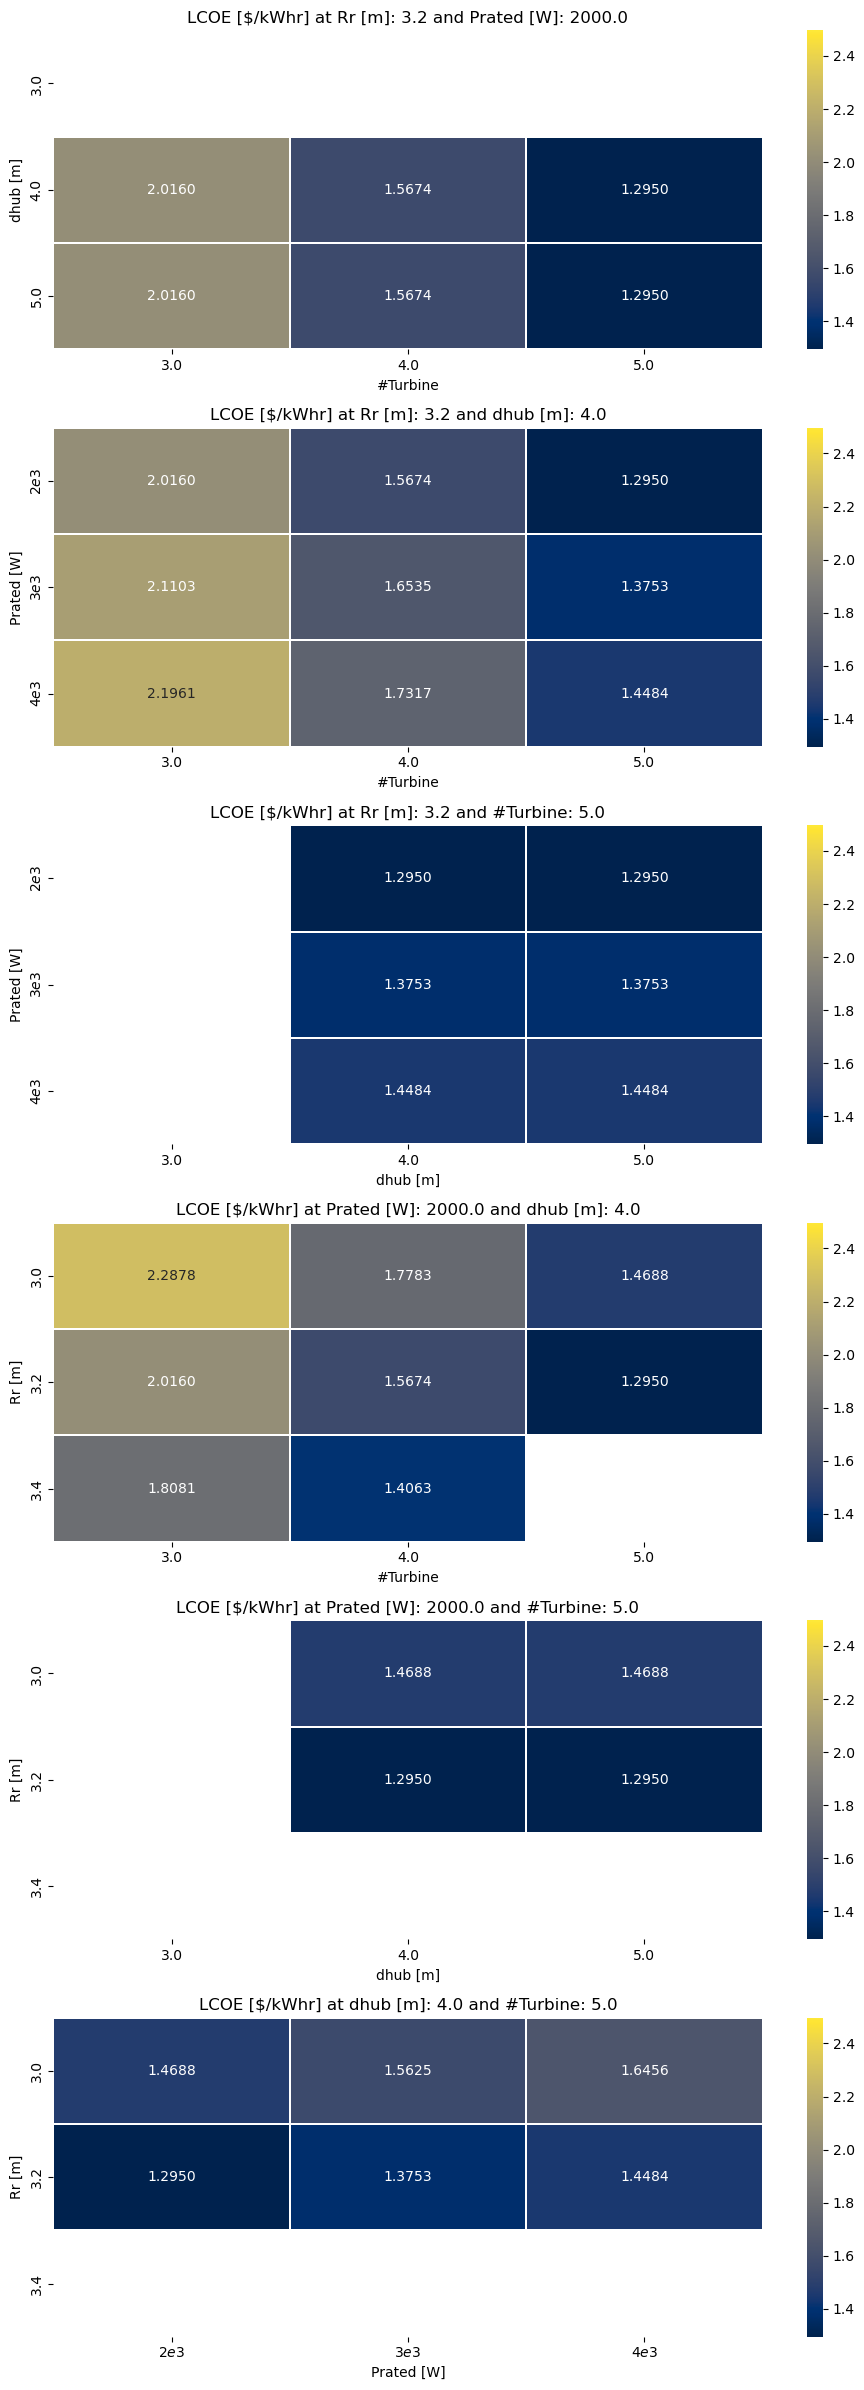

In [14]:
# Process the output of the brute force optimization
funcMain.processBruteOutput(xopt, fval, grid, Jout, station, startdate, VESSEL, Umin, withBrake)


## Step 7: Plot Results at Optimal Point

In this step, we will plot the results obtained at the optimal point found through brute force optimization.  

In [16]:
# Extract optimal parameters from the optimization output
Radius, Prated, dHub, NumTurbine = xopt

# Simulate rotor dynamics using the optimal parameters
w, Tc, Pmech, Pelec, Phydro, Pfluid, Punc, TSR, Ft, Th = funcSimRotor.simRotor(
    Radius, Prated, dHub, dMoor, Uinf, t, CpFunc, CtFunc, CpOpt, TSROpt, bladeRadius, bladeMass, Umin, withBrake
)

# Update flow speed at depth
Uinf_update = funcTidal.flowAtDepth(Uinf, Radius, dHub, dMoor)

# Calculate vessel thrust force
F_vessel_thrust = funcConstraint.calForceMoorThrustFunc(Uinf_update, VESSEL)

# Calculate turbine thrust force
F_turbine_thrust = funcSimRotor.calForceThrustFunc(Radius, Uinf_update, CtFunc(TSR))

# Calculate the Levelized Cost of Energy (LCOE) and cost breakdown
LCOE, CostBreakdown = funcLCOE.calculate_cost(
    Radius, Prated, NumTurbine, dCable, dMoor, F_vessel_thrust, F_turbine_thrust, Pelec, t
)


Running rotor simulation for Radius = 3.2, Prated = 2000.0, dHub = 4.0.


## Analyzing and Visualizing Results

In this step, we will:

1. **Print the Cost Breakdown**: Use the built-in function to print a detailed breakdown of the costs.
2. **Print Rotor Dynamic Simulation Statistics**: Use the built-in function to print the statistics of the rotor dynamic simulation results.
3. **Plot Time Domain Dynamics**: Use the built-in function to visualize the time domain dynamic plots.


Cost Breakdown:
LCOE: $1.30
CAPEX: $147431.19
Et: $17925.93
cable: $25179.42
grid connect: $284.86
moor: $6135.76
blade: $1189.92
generator: $4835.72
misc: $470.02
hub: $2107.97
cable install: $100206.99
Rotor Dynamics (Mean) [SI units are assumed]:
w: 0.43
Tc: 708.33
TSR: 4.33
Pmech: 454.74
Pelec: 409.27
Phydro: 455.45
Pfluid: 1049.48
Punc: 459.87
Ft: 1808.61
Th: 709.09
Rotor Dynamics (Max) [SI units are assumed]:
w: 0.93
Tc: 2442.95
TSR: 32.25
Pmech: 2222.22
Pelec: 2000.00
Phydro: 2379.41
Pfluid: 5484.28
Punc: 2403.14
Ft: 6526.89
Th: 2548.39


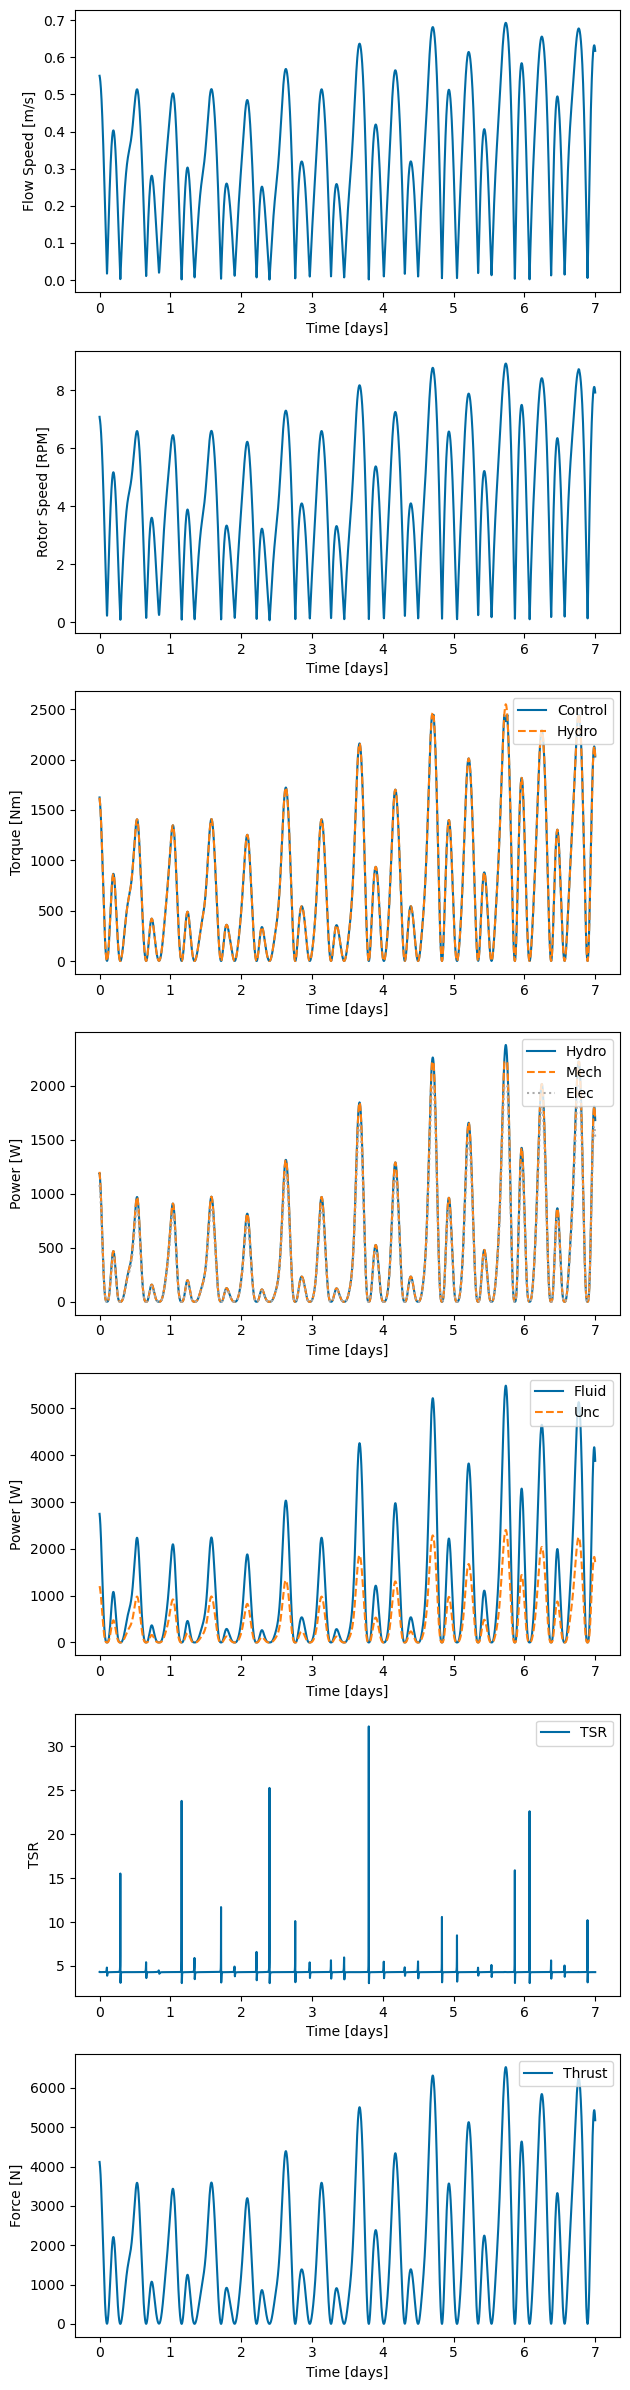

In [17]:
# Print the cost breakdown
funcLCOE.printCostBreakdown(CostBreakdown)

# Print the rotor simulation statistics
funcSimRotor.printSimRotorStatistic(w, Tc, Pmech, Pelec, Phydro, Pfluid, Punc, TSR, Ft, Th)

# Plot the time domain results of the rotor simulation
funcSimRotor.plotTimeDomainResult(
    Uinf, t, w, Tc, Pmech, Pelec, Phydro, Pfluid, Punc, TSR, Ft, Th, 
    station, startdate, VESSEL, Umin, withBrake
)


## Visualizing Vessel Pitch Constraint

In this step, we will use the built-in function to visualize the vessel pitch constraint. This helps in assessing whether the vessel operates within safe pitch limits under the given conditions.

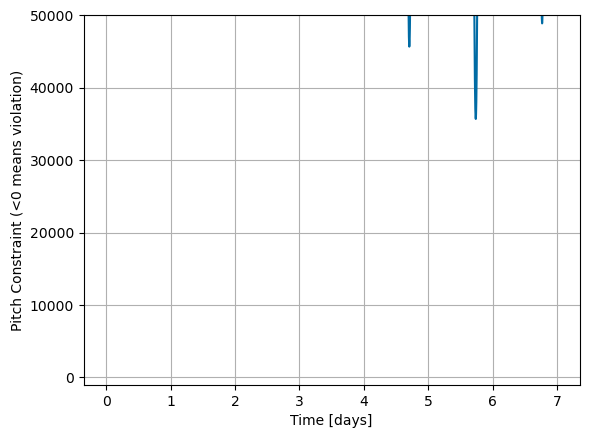

In [18]:
# Define y-axis limits for plotting the graph
ylim = [-1000, 50000]

# Plot the pitch constraint
funcConstraint.plotPitchCon(
    Radius, dHub, dMoor, Uinf, CtFunc, TSR, VESSEL, NumTurbine, t, ylim
)


## Visualizing Cavitation Constraint

In this step, we will use the built-in function to visualize the cavitation constraint. This helps in understanding whether the rotor operates within safe limits to avoid cavitation.

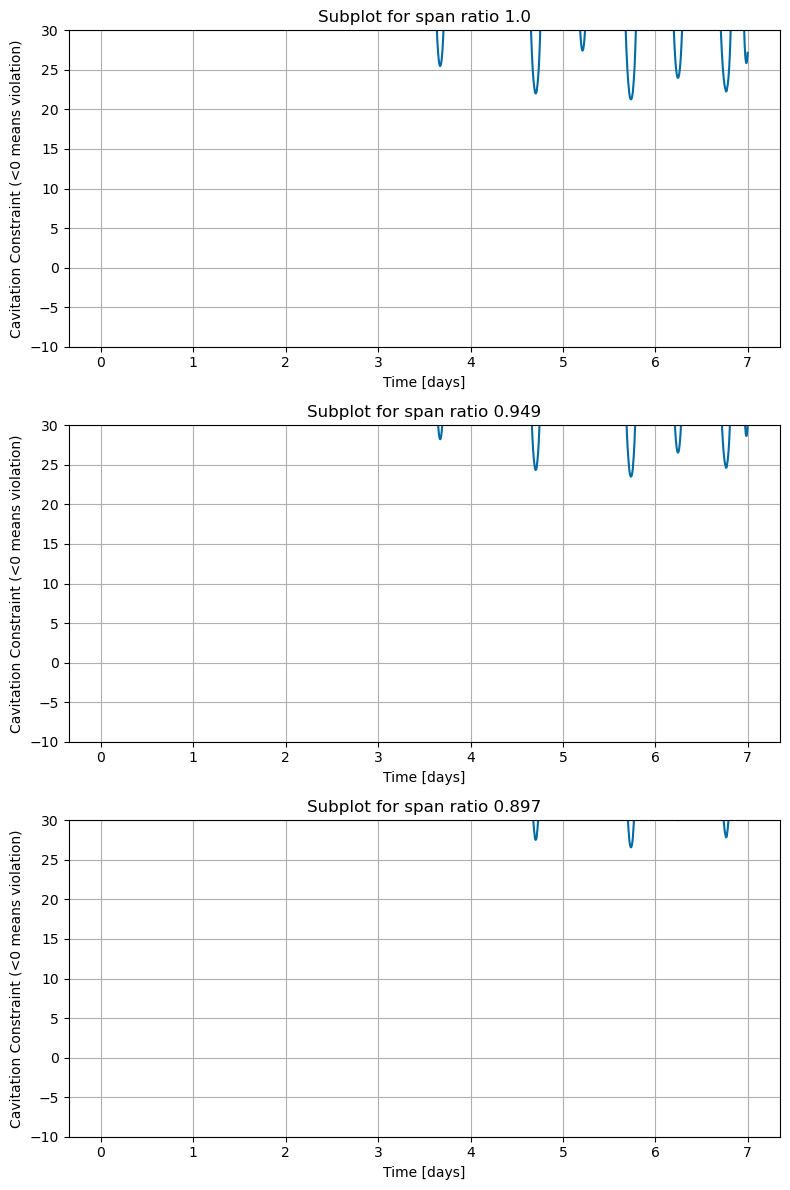

In [19]:
import importlib

# Reload the funcConstraint module to ensure the latest version is used
importlib.reload(funcConstraint)

# Define y-axis limits for plotting the graph
ylim = [-10, 30]

# Plot the cavitation constraint
funcConstraint.plotCavitationCon(
    Radius, dHub, dMoor, Uinf, w, TSR, CpminFunc, spanRatio, t, ylim
)
